# Predicting Stock Market Betas for Equity Pairs - Exploratory Data Analysis
This Jupyter notebook contains the initial work and exploratory data analysis performed for my Capstone Project, in which I selected a single equity pair, XLK and SPY, and performed the required data cleaning, validation, & preperation, some data analysis, and then some feature extraction and simple regression modelling in order to gather a set of initial results to demonstrate the validity of the approach.

In [1]:
import databento as db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Confirm Databento version
print(f"Imported Databento version: {db.__version__}")

Imported Databento version: 0.68.1


## 1 Data Cleaning and Validation
For this project, I created an account with the data vendor Databento, and then downloaded one-minute Best Bid & Offer (BBO) data for selected equities.<br>
First we need to load the raw data, filter it, and check it for errors and missing values.

### 1.1 Load Data

Load the previously downloaded one-minute BBO data for SPY & XLK into Databento stores:

In [2]:
# Create Databento stores for SPY & XLK from the raw DBN files compressed with ZST, for data from 2018-05-01 through 2025-12-31
print("Creating Databento stores for SPY & XLK ...")
store_SPY = db.DBNStore.from_file("Data/Prototype 01/01.04 Download/xnas-itch-20180501-20251231.bbo-1m.SPY.dbn.zst")
store_XLK = db.DBNStore.from_file("Data/Prototype 01/01.04 Download/xnas-itch-20180501-20251231.bbo-1m.XLK.dbn.zst")
print("Done")

Creating Databento stores for SPY & XLK ...
Done


Create separate Dataframes for SPY & XLK raw data, with timestamps in local time:

In [3]:
# Create DataFrames from the stores, converting to local time and accounting for DST
print("Creating DataFrames from stores, with timestamps in local time ...")
df_raw_SPY = store_SPY.to_df(tz="America/Los_Angeles")
df_raw_XLK = store_XLK.to_df(tz="America/Los_Angeles")

# Confirm the date ranges
print(f"Date range in SPY raw data: {df_raw_SPY.index.min()} to {df_raw_SPY.index.max()}")
print(f"Date range in XLK raw data: {df_raw_XLK.index.min()} to {df_raw_XLK.index.max()}")
print("Done")

Creating DataFrames from stores, with timestamps in local time ...
Date range in SPY raw data: 2018-05-01 01:01:00-07:00 to 2025-12-31 15:59:00-08:00
Date range in XLK raw data: 2018-05-01 04:01:00-07:00 to 2025-12-31 15:48:00-08:00
Done


Create additional DataFrames for 2025 only and output .csv files to inspect the raw data in Excel:<br>
**(This step can be skipped in subsequent passes)**

In [4]:
# Create DataFrames for raw data for 2025 only
print("Creating DataFrames for raw data for 2025 only ...")
df_raw_SPY_2025 = df_raw_SPY[df_raw_SPY.index.year == 2025].copy()
df_raw_XLK_2025 = df_raw_XLK[df_raw_XLK.index.year == 2025].copy()

# Confirm the date ranges for 2025 only
print(f"Date range in SPY raw data for 2025 only: {df_raw_SPY_2025.index.min()} to {df_raw_SPY_2025.index.max()}")
print(f"Date range in XLK raw data for 2025 only: {df_raw_XLK_2025.index.min()} to {df_raw_XLK_2025.index.max()}")
print("Done")

# Write CSV files with the 2025 data
print()
print("Writing CSV files with 2025 raw data for SPY & XLK ...")
df_raw_SPY_2025.to_csv("Data/Prototype 01/01.04 Processed/RawSPY2025.csv")
df_raw_XLK_2025.to_csv("Data/Prototype 01/01.04 Processed/RawXLK2025.csv")
print("Done")

Creating DataFrames for raw data for 2025 only ...
Date range in SPY raw data for 2025 only: 2025-01-02 01:01:00-08:00 to 2025-12-31 15:59:00-08:00
Date range in XLK raw data for 2025 only: 2025-01-02 01:01:00-08:00 to 2025-12-31 15:48:00-08:00
Done

Writing CSV files with 2025 raw data for SPY & XLK ...
Done


In [5]:
df_raw_SPY.head()

,ts_event,rtype,publisher_id,instrument_id,side,price,size,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,
2018-05-01 01:01:00-07:00,NaT,196,2,7177,N,NaN,0,130,229774,238.53,NaN,100,0,1,0,SPY
2018-05-01 01:02:00-07:00,NaT,196,2,7177,N,NaN,0,130,237675,264.52,264.69,1000,1000,1,2,SPY
2018-05-01 01:03:00-07:00,NaT,196,2,7177,N,NaN,0,130,244076,264.52,264.67,1000,1000,1,1,SPY
2018-05-01 01:04:00-07:00,NaT,196,2,7177,N,NaN,0,130,250299,264.56,264.64,1000,500,1,1,SPY
2018-05-01 01:05:00-07:00,2018-05-01 01:04:24.986914153-07:00,196,2,7177,A,264.57,20,130,258645,264.52,264.58,1000,500,1,1,SPY


In [6]:
df_raw_SPY.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1751579 entries, 2018-05-01 01:01:00-07:00 to 2025-12-31 15:59:00-08:00
Data columns (total 16 columns):
 #   Column         Dtype                              
---  ------         -----                              
 0   ts_event       datetime64[ns, America/Los_Angeles]
 1   rtype          uint8                              
 2   publisher_id   uint16                             
 3   instrument_id  uint32                             
 4   side           object                             
 5   price          float64                            
 6   size           uint32                             
 7   flags          uint8                              
 8   sequence       uint32                             
 9   bid_px_00      float64                            
 10  ask_px_00      float64                            
 11  bid_sz_00      uint32                             
 12  ask_sz_00      uint32                             
 1

In [7]:
df_raw_SPY.describe()

,rtype,publisher_id,instrument_id,price,size,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00
count,1751579.0,1751579.0,1.751579e+06,1.750439e+06,1.751579e+06,1.751579e+06,1.751579e+06,1.751534e+06,1.751475e+06,1.751579e+06,1.751579e+06,1.751579e+06,1.751579e+06
mean,196.0,2.0,1.037438e+04,4.202531e+02,1.389280e+02,1.299034e+02,2.435327e+08,4.201681e+02,4.203377e+02,6.587623e+02,6.850061e+02,2.601778e+00,2.605008e+00
std,0.0,0.0,3.095331e+03,1.151734e+02,3.294732e+02,1.077204e+00,2.533603e+08,1.151764e+02,1.897969e+02,9.920895e+02,1.086952e+03,2.283292e+00,2.263691e+00
min,196.0,2.0,7.177000e+03,2.184400e+02,0.000000e+00,0.000000e+00,2.129390e+05,2.184300e+02,2.184500e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,196.0,2.0,7.454000e+03,3.136800e+02,1.600000e+01,1.300000e+02,8.536590e+06,3.135800e+02,3.136200e+02,2.000000e+02,2.000000e+02,1.000000e+00,1.000000e+00
50%,196.0,2.0,9.533000e+03,4.121700e+02,1.000000e+02,1.300000e+02,1.922315e+08,4.121200e+02,4.121600e+02,4.630000e+02,5.000000e+02,2.000000e+00,2.000000e+00
75%,196.0,2.0,1.514400e+04,4.925400e+02,1.000000e+02,1.300000e+02,4.152086e+08,4.923500e+02,4.924100e+02,8.000000e+02,8.000000e+02,3.000000e+00,3.000000e+00
max,196.0,2.0,1.514400e+04,6.915600e+02,7.215900e+04,1.340000e+02,2.365089e+09,6.915500e+02,2.000000e+05,2.097000e+05,2.322130e+05,2.480000e+02,9.800000e+01


### 1.2 Filter Unnecessary Data

Remove all the data rows that fall outside of the regular trading sessions, accounting for early closures on "half days". We want to keep the rows with one-minute data that starts one minute after the open and ends exactly on the close.

In [8]:
# Get a list of the "half days" when the regular market closes three hours early
df_half_days = pd.read_csv("Data/nyse_half_days_2018-05-01_to_2025-12-31.csv")

# There are various ways to select datatypes and filterings, experimentation has yielded the following results:
half_days  = pd.to_datetime(df_half_days["Date"]).values.astype("datetime64[D]") # This datatype appears to be fastest for filtering
    # This can be filtered with either of these:
    #    np.isin(df_raw_SPY.index.values.astype("datetime64[D]"), half_days)     # This is slightly faster and is used below
    #    pd.Index(df_raw_SPY.index.values.astype("datetime64[D]")).isin(half_days)
#half_days = pd.to_datetime(df_half_days['Date']).dt.date                        # This appears to be slower
    # In this case, filter with either of these:
    #    np.isin(df_raw_SPY.index.date, half_days)
    #    pd.Index(df_raw_SPY.index.date).isin(half_days)                         # This was slightly faster in testing
#half_days = pd.to_datetime(df_half_days["Date"]).dt.normalize()                 # This appears to be the slowest (keeping datetime64[ns] and truncating)
    # In this case, filter with:
    #    df_raw_SPY.index.normalize().isin(half_days)

# Define regular trading session hours in New York time
ny_market_open        = pd.Timestamp('09:30:00').tz_localize('America/New_York')
ny_market_close_early = pd.Timestamp('13:00:00').tz_localize('America/New_York') # For half days (before or after certain holidays)
ny_market_close       = pd.Timestamp('16:00:00').tz_localize('America/New_York')

# Convert New York trading session hours to the data's timezone (using SPY as the example for all)
data_timezone = df_raw_SPY.index.tz
local_market_open        = ny_market_open.tz_convert(data_timezone)
local_market_close_early = ny_market_close_early.tz_convert(data_timezone)
local_market_close       = ny_market_close.tz_convert(data_timezone)

# Get just the time components
local_market_time_open        = local_market_open.time()
local_market_time_close_early = local_market_close_early.time()
local_market_time_close       = local_market_close.time()

# Filter the data to include only the regular trading session (and create copies before modifying the data)
print(f"Extracting regular session data from {local_market_time_open} (exclusive) to {local_market_time_close} (inclusive) local time ...")
df_SPY = df_raw_SPY[
    (~np.isin(df_raw_SPY.index.values.astype("datetime64[D]"), half_days) & (df_raw_SPY.index.time > local_market_time_open) & (df_raw_SPY.index.time <= local_market_time_close)) |
    ( np.isin(df_raw_SPY.index.values.astype("datetime64[D]"), half_days) & (df_raw_SPY.index.time > local_market_time_open) & (df_raw_SPY.index.time <= local_market_time_close_early))
].copy()
df_XLK = df_raw_XLK[
    (~np.isin(df_raw_XLK.index.values.astype("datetime64[D]"), half_days) & (df_raw_XLK.index.time > local_market_time_open) & (df_raw_XLK.index.time <= local_market_time_close)) |
    ( np.isin(df_raw_XLK.index.values.astype("datetime64[D]"), half_days) & (df_raw_XLK.index.time > local_market_time_open) & (df_raw_XLK.index.time <= local_market_time_close_early))
].copy()

# Show the results of the filtering
print(f"Original DataFrame shape for SPY: {df_raw_SPY.shape}")
print(f"Original DataFrame shape for XLK: {df_raw_XLK.shape}")
print(f"Filtered DataFrame shape for SPY: {df_SPY.shape}")
print(f"Filtered DataFrame shape for XLK: {df_XLK.shape}")
print("Done")

Extracting regular session data from 06:30:00 (exclusive) to 13:00:00 (inclusive) local time ...
Original DataFrame shape for SPY: (1751579, 16)
Original DataFrame shape for XLK: (1323872, 16)
Filtered DataFrame shape for SPY: (749017, 16)
Filtered DataFrame shape for XLK: (749012, 16)
Done


Now create additional regular session DataFrames for 2025 only and output .csv files to inspect the data in Excel:<br>
**(This step can be skipped in subsequent passes)**

In [10]:
# Create DataFrames for regular session 2025 only
print("Creating DataFrames for 2025 only ...")
df_SPY_2025 = df_SPY[df_SPY.index.year == 2025].copy()
df_XLK_2025 = df_XLK[df_XLK.index.year == 2025].copy()

# Confirm the date ranges
print(f"Date range in SPY for 2025 only: {df_SPY_2025.index.min()} to {df_SPY_2025.index.max()}")
print(f"Date range in XLK for 2025 only: {df_XLK_2025.index.min()} to {df_XLK_2025.index.max()}")
print("Done")

# Write CSV files with the 2025 data
print()
print("Writing CSV files with 2025 data for SPY & XLK ...")
df_SPY_2025.to_csv("Data/Prototype 01/01.04 Processed/SPY2025.csv")
df_XLK_2025.to_csv("Data/Prototype 01/01.04 Processed/XLK2025.csv")
print("Done")

Creating DataFrames for 2025 only ...
Date range in SPY for 2025 only: 2025-01-02 06:31:00-08:00 to 2025-12-31 13:00:00-08:00
Date range in XLK for 2025 only: 2025-01-02 06:31:00-08:00 to 2025-12-31 13:00:00-08:00
Done

Writing CSV files with 2025 data for SPY & XLK ...
Done


Now that we've removed all the unnecessary rows, we will remove all the unnecesary columns, and keep only the BBO price data:

In [11]:
df_SPY = df_SPY[['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00']]
df_XLK = df_XLK[['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00']]

In [12]:
df_SPY.head()

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
ts_recv,,,,
2018-05-01 06:31:00-07:00,263.77,263.78,527,200
2018-05-01 06:32:00-07:00,263.76,263.78,6400,201
2018-05-01 06:33:00-07:00,263.75,263.77,2400,500
2018-05-01 06:34:00-07:00,263.62,263.65,6600,2600
2018-05-01 06:35:00-07:00,263.65,263.68,6473,801


### 1.3 Validate Data

Now we need to inspect the data for errors and missing value.

First let's check the timestamps for uniqueness, increasing order, and exact alignment on one-minute boundaries:

In [13]:
# Check that the timestamp index is unique and monotonically increasing
print("Validating timestamps ...")
print()
print("SPY timestamps are unique and increasing:", df_SPY.index.is_unique and df_SPY.index.is_monotonic_increasing)
print("XLK timestamps are unique and increasing:", df_XLK.index.is_unique and df_XLK.index.is_monotonic_increasing)

# Check that the timestamp index falls exactly on a one-minute boundary
print()
print("SPY timestamps are all exactly on one-minute boundaries:", (df_SPY.index.second      == 0).all() and
                                                                  (df_SPY.index.microsecond == 0).all() and
                                                                  (df_SPY.index.nanosecond  == 0).all())
print("XLK timestamps are all exactly on one-minute boundaries:", (df_XLK.index.second      == 0).all() and
                                                                  (df_XLK.index.microsecond == 0).all() and
                                                                  (df_XLK.index.nanosecond  == 0).all())
print()
print("Done")

Validating timestamps ...

SPY timestamps are unique and increasing: True
XLK timestamps are unique and increasing: True

SPY timestamps are all exactly on one-minute boundaries: True
XLK timestamps are all exactly on one-minute boundaries: True

Done


Looks good. Now we'll check for missing (null) values in the BBO data fields:

In [14]:
print(df_SPY.info())
print()
print(df_XLK.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 749017 entries, 2018-05-01 06:31:00-07:00 to 2025-12-31 13:00:00-08:00
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   bid_px_00  749017 non-null  float64
 1   ask_px_00  749017 non-null  float64
 2   bid_sz_00  749017 non-null  uint32 
 3   ask_sz_00  749017 non-null  uint32 
dtypes: float64(2), uint32(2)
memory usage: 39.0 MB
None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 749012 entries, 2018-05-01 06:31:00-07:00 to 2025-12-31 13:00:00-08:00
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   bid_px_00  749012 non-null  float64
 1   ask_px_00  749012 non-null  float64
 2   bid_sz_00  749012 non-null  uint32 
 3   ask_sz_00  749012 non-null  uint32 
dtypes: float64(2), uint32(2)
memory usage: 39.0 MB
None


There don't appear to be any missing values in those fields, although we can already tell from the different numbers of rows in the datasets that there are some missing rows in the data.

To check the BBO price data for outliers, for now we'll just make sure that min-max and quartile data looks good:

In [15]:
print(df_SPY.describe())
print()
print(df_XLK.describe())

           bid_px_00      ask_px_00      bid_sz_00      ask_sz_00
count  749017.000000  749017.000000  749017.000000  749017.000000
mean      419.568141     419.581557     652.445137     679.165994
std       115.216326     115.217926     959.702136    1055.891392
min       218.430000     218.450000       1.000000       1.000000
25%       312.680000     312.690000     200.000000     200.000000
50%       411.570000     411.590000     400.000000     400.000000
75%       487.810000     487.820000     760.000000     793.000000
max       691.550000     691.560000   75270.000000  232213.000000

           bid_px_00      ask_px_00      bid_sz_00      ask_sz_00
count  749012.000000  749012.000000  749012.000000  749012.000000
mean      147.983361     147.997882    1152.678006    1166.725538
std        59.222847      59.226563    2252.201849    2282.555289
min        57.580000      57.600000       1.000000       1.000000
25%        94.570000      94.580000     180.000000     180.000000
50%      

All these values look within reason.

Now we need to examine the missing rows. First, for efficiency, we'll add a date column from the index timestamp:

In [16]:
# Add a column with just the date
df_SPY['date'] = df_SPY.index.date
df_XLK['date'] = df_XLK.index.date

In [17]:
df_SPY.head()

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,date
ts_recv,,,,,
2018-05-01 06:31:00-07:00,263.77,263.78,527,200,2018-05-01
2018-05-01 06:32:00-07:00,263.76,263.78,6400,201,2018-05-01
2018-05-01 06:33:00-07:00,263.75,263.77,2400,500,2018-05-01
2018-05-01 06:34:00-07:00,263.62,263.65,6600,2600,2018-05-01
2018-05-01 06:35:00-07:00,263.65,263.68,6473,801,2018-05-01


Let's start by looking at the number of trading dates represented:

In [18]:
print(f"Number of distinct trading dates in the dataset for SPY: {df_SPY['date'].nunique()}")
print(f"Number of distinct trading dates in the dataset for XLK: {df_XLK['date'].nunique()}")

Number of distinct trading dates in the dataset for SPY: 1929
Number of distinct trading dates in the dataset for XLK: 1929


There don't appear to be any missing trading dates for SPY & XLK.

Now let's look at how much intraday data is missing, by counting the number of rows present for each date, and then displaying the number of dates with each number of rows:

In [19]:
# Count the number of rows present for each date
df_daily_counts_SPY = df_SPY.groupby(df_SPY['date']).size().to_frame("row_count")
df_daily_counts_XLK = df_XLK.groupby(df_XLK['date']).size().to_frame("row_count")

# Show the number of dates with each number of rows
print("Number of dates for each row count for SPY:")
print(df_daily_counts_SPY.groupby('row_count').size())
print()
print("Number of dates for each row count for XLK:")
print(df_daily_counts_XLK.groupby('row_count').size())

Number of dates for each row count for SPY:
row_count
210      18
376       1
377       1
379       2
386       1
390    1906
dtype: int64

Number of dates for each row count for XLK:
row_count
210      18
376       2
377       2
386       1
390    1906
dtype: int64


There should be 210 rows for half days, of which there are 18, and 390 rows for full days. From these results it looks like there are a handful of days with some missing rows, but that should not present too much of a problem.

## 2 Data Preparation
Next, we need to prepare the data for modeling by calculating the daily Betas for XLK/SPY.

### 2.1 Calculate 1-Minute Prices

First we need to calculate and add the one-minute prices from the BBO data. A choice we'll need to make is whether to use a weighted midpoint of best bid and offer, using the bid and ask sizes, or just the exact midpoint between best bid and offer. (We don't want to use the last trade for this kind of analysis, because that would lead to a "bid-ask bounce"). For now we'll do both:

***NOTE FOR LATER: After deciding whether to use wtd_price or mid_price, I might want to come back and just do one.***

In [20]:
# Calculate the price at one-minute intervals from the best bid and offer, weighted by the bid and offer sizes
df_SPY['wtd_price'] = ((df_SPY['ask_sz_00'] * df_SPY['bid_px_00']) + (df_SPY['bid_sz_00'] * df_SPY['ask_px_00'])) / (df_SPY['ask_sz_00'] + df_SPY['bid_sz_00'])
df_XLK['wtd_price'] = ((df_XLK['ask_sz_00'] * df_XLK['bid_px_00']) + (df_XLK['bid_sz_00'] * df_XLK['ask_px_00'])) / (df_XLK['ask_sz_00'] + df_XLK['bid_sz_00'])

# Calculate the midpoint price at one-minute intervals
df_SPY['mid_price'] = (df_SPY['bid_px_00'] + df_SPY['ask_px_00']) / 2
df_XLK['mid_price'] = (df_XLK['bid_px_00'] + df_XLK['ask_px_00']) / 2

# Diplay the result
df_SPY.head()

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,date,wtd_price,mid_price
ts_recv,,,,,,,
2018-05-01 06:31:00-07:00,263.77,263.78,527,200,2018-05-01,263.777249,263.775
2018-05-01 06:32:00-07:00,263.76,263.78,6400,201,2018-05-01,263.779391,263.770
2018-05-01 06:33:00-07:00,263.75,263.77,2400,500,2018-05-01,263.766552,263.760
2018-05-01 06:34:00-07:00,263.62,263.65,6600,2600,2018-05-01,263.641522,263.635
2018-05-01 06:35:00-07:00,263.65,263.68,6473,801,2018-05-01,263.676696,263.665


We no longer need the BBO data, so we can drop it now:

In [21]:
df_SPY.drop(['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00'], axis=1, inplace=True)
df_XLK.drop(['bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00'], axis=1, inplace=True)
df_SPY.head()

,date,wtd_price,mid_price
ts_recv,,,
2018-05-01 06:31:00-07:00,2018-05-01,263.777249,263.775
2018-05-01 06:32:00-07:00,2018-05-01,263.779391,263.770
2018-05-01 06:33:00-07:00,2018-05-01,263.766552,263.760
2018-05-01 06:34:00-07:00,2018-05-01,263.641522,263.635
2018-05-01 06:35:00-07:00,2018-05-01,263.676696,263.665


### 2.2 Calculate 1-Minute Returns

Now we'll add the price changes, calculated as log-returns over one-minute intervals. If the interval to the previous data snapshot is more than one minute, the data will be dropped.

***NOTE FOR LATER: It might be better to calculate returns over a 5-minute interval, but do it at 1-minute increments.***

First, add columns for the time interval between rows and the log returns over those intervals:

In [22]:
# Add a column for the interval (in seconds) between the previous timestamp and the current timestamp
df_SPY['interval_secs'] = df_SPY.index.to_series().diff().dt.total_seconds()
df_XLK['interval_secs'] = df_XLK.index.to_series().diff().dt.total_seconds()

# Calculate the log return for the interval between the previous timestamp and the current timestamp
df_SPY['log_return_mid'] = np.log(df_SPY['mid_price'] / df_SPY['mid_price'].shift(1))
df_XLK['log_return_mid'] = np.log(df_XLK['mid_price'] / df_XLK['mid_price'].shift(1))

# Show a sample of data
df_SPY.head()

,date,wtd_price,mid_price,interval_secs,log_return_mid
ts_recv,,,,,
2018-05-01 06:31:00-07:00,2018-05-01,263.777249,263.775,NaN,NaN
2018-05-01 06:32:00-07:00,2018-05-01,263.779391,263.770,60.0,-0.000019
2018-05-01 06:33:00-07:00,2018-05-01,263.766552,263.760,60.0,-0.000038
2018-05-01 06:34:00-07:00,2018-05-01,263.641522,263.635,60.0,-0.000474
2018-05-01 06:35:00-07:00,2018-05-01,263.676696,263.665,60.0,0.000114


Let's take a look at the counts of each interval length:

In [23]:
print(df_SPY['interval_secs'].value_counts().sort_index())
print()
print(df_XLK['interval_secs'].value_counts().sort_index())

interval_secs
60.0        747077
120.0            2
180.0            1
240.0            2
300.0            2
360.0            1
540.0            2
900.0            1
63060.0       1505
149460.0        15
160260.0         8
232260.0         7
235860.0       327
239460.0         8
246660.0         8
322260.0        48
333060.0         2
Name: count, dtype: int64

interval_secs
60.0        747078
300.0            1
840.0            2
900.0            2
63060.0       1505
149460.0        15
160260.0         8
232260.0         7
235860.0       327
239460.0         8
246660.0         8
322260.0        48
333060.0         2
Name: count, dtype: int64


Now we can drop the rows for which the time interval is not 1 minute:

In [24]:
# Drop the rows for which the interval is not exactly 1 minute
df_SPY = df_SPY[df_SPY['interval_secs'] == 60.0]
df_XLK = df_XLK[df_XLK['interval_secs'] == 60.0]

# Confirm that only one-minute intervals remain
print(df_SPY['interval_secs'].value_counts().sort_index())
print()
print(df_XLK['interval_secs'].value_counts().sort_index())

interval_secs
60.0    747077
Name: count, dtype: int64

interval_secs
60.0    747078
Name: count, dtype: int64


In [26]:
df_SPY.head()

,date,wtd_price,mid_price,interval_secs,log_return_mid
ts_recv,,,,,
2018-05-01 06:32:00-07:00,2018-05-01,263.779391,263.770,60.0,-0.000019
2018-05-01 06:33:00-07:00,2018-05-01,263.766552,263.760,60.0,-0.000038
2018-05-01 06:34:00-07:00,2018-05-01,263.641522,263.635,60.0,-0.000474
2018-05-01 06:35:00-07:00,2018-05-01,263.676696,263.665,60.0,0.000114
2018-05-01 06:36:00-07:00,2018-05-01,263.625577,263.625,60.0,-0.000152


### 2.3 Join Pairs of Returns

Now we can join together the returns for pairs of equities (only XLK/SPY so far) at each 1-minute interval:

In [27]:
# Join the returns for SPY & XLK
df_SPY_XLK = df_SPY[['date', 'mid_price', 'log_return_mid']].join(df_XLK[['mid_price', 'log_return_mid']], how='inner', lsuffix='_spy', rsuffix='_xlk')

In [28]:
# Examine the joined results
print(df_SPY_XLK.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 747077 entries, 2018-05-01 06:32:00-07:00 to 2025-12-31 13:00:00-08:00
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   date                747077 non-null  object 
 1   mid_price_spy       747077 non-null  float64
 2   log_return_mid_spy  747077 non-null  float64
 3   mid_price_xlk       747077 non-null  float64
 4   log_return_mid_xlk  747077 non-null  float64
dtypes: float64(4), object(1)
memory usage: 34.2+ MB
None


In [29]:
df_SPY_XLK.head()

,date,mid_price_spy,log_return_mid_spy,mid_price_xlk,log_return_mid_xlk
ts_recv,,,,,
2018-05-01 06:32:00-07:00,2018-05-01,263.770,-0.000019,65.425,0.000688
2018-05-01 06:33:00-07:00,2018-05-01,263.760,-0.000038,65.455,0.000458
2018-05-01 06:34:00-07:00,2018-05-01,263.635,-0.000474,65.425,-0.000458
2018-05-01 06:35:00-07:00,2018-05-01,263.665,0.000114,65.405,-0.000306
2018-05-01 06:36:00-07:00,2018-05-01,263.625,-0.000152,65.345,-0.000918


Let's look at a scatter plot for all of the paired returns, for XLK/SPY:

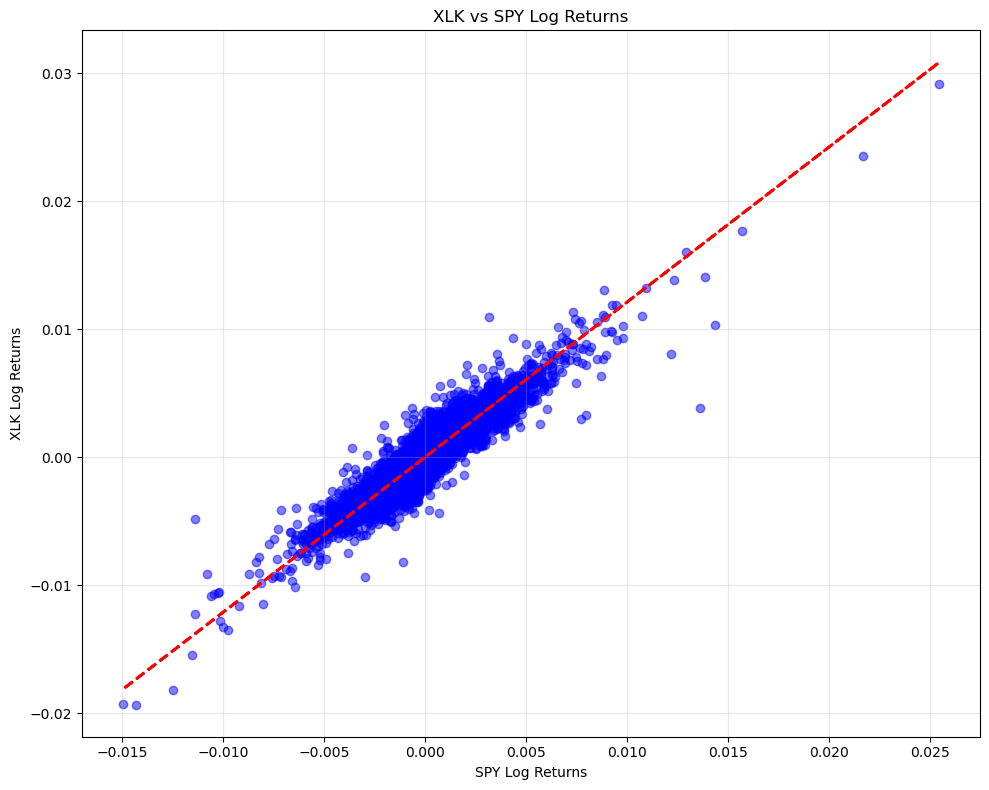

In [30]:
# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(df_SPY_XLK['log_return_mid_spy'], df_SPY_XLK['log_return_mid_xlk'], alpha=0.5, color='blue')

# Add a trend line
z = np.polyfit(df_SPY_XLK['log_return_mid_spy'], df_SPY_XLK['log_return_mid_xlk'], 1)
p = np.poly1d(z)
plt.plot(df_SPY_XLK['log_return_mid_spy'], p(df_SPY_XLK['log_return_mid_spy']), 'r--', linewidth=2)

# Add labels, title, and grid
plt.xlabel('SPY Log Returns')
plt.ylabel('XLK Log Returns')
plt.title('XLK vs SPY Log Returns')
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

### 2.4 Calculate Daily Betas

Now we can use the returns for pairs of equities to calculate the beta for each trading date.

Here the betas are calculated for XLK/SPY:

In [31]:
# Define column names x and y for the beta calculation
x = "log_return_mid_spy"
y = "log_return_mid_xlk"

# There are two ways to do this; this is the slow way:

# # Calculate betas for each day and convert to a dataframe
# df_SPY_XLK_betas = (
#     df_SPY_XLK[["date", x, y]]
#       .groupby("date")[[x, y]]
#       .apply(lambda g: ((g[x] * g[y]).sum() / (g[x] ** 2).sum())
#                       if (g[x] ** 2).sum() != 0 else np.nan)
#       .to_frame("xlk_spy_beta")
# )

# And this is the faster way:

# Calculate betas for each day and convert to a dataframe
tmp = df_SPY_XLK[["date", x, y]]
num = (tmp[x] * tmp[y]).groupby(tmp["date"]).sum()
den = (tmp[x] ** 2).groupby(tmp["date"]).sum()
beta = num / den.replace(0, np.nan)
df_SPY_XLK_betas = beta.to_frame("xlk_spy_beta")

# Show the results
df_SPY_XLK_betas

,xlk_spy_beta
date,
2018-05-01,1.142436
2018-05-02,1.195854
2018-05-03,1.128075
2018-05-04,1.160622
2018-05-07,1.246262
...,...
2025-12-24,1.240195
2025-12-26,1.416970
2025-12-29,1.818929


### 2.5 Save/Reload Daily Betas

At this point we'll save the daily betas to .csv files so they can be reloaded without running all the previous steps:<br>
**(This step can be skipped in subsequent passes)**

In [32]:
# Write .csv files with the daily betas
print("Writing CSV files with daily betas for XLK/SPY ...")
df_SPY_XLK_betas.to_csv("Data/Prototype 01/01.04 Processed/Daily Betas XLK-SPY.csv")
print("Done")

Writing CSV files with daily betas for XLK/SPY ...
Done


**RESTART HERE:** From this cell we can reload the daily betas from the .csv files without running all the previous steps (after running the import code cell):

In [33]:
# Reload daily betas from .csv files
df_SPY_XLK_betas = pd.read_csv("Data/Prototype 01/01.04 Processed/Daily Betas XLK-SPY.csv", index_col=0)

## 3 Data Analysis
Now let's take a look at the characteristics of the daily betas for XLK/SPY.

#### 3.1 Histograms

First let's examine a histogram of the betas, for XLK/SPY:

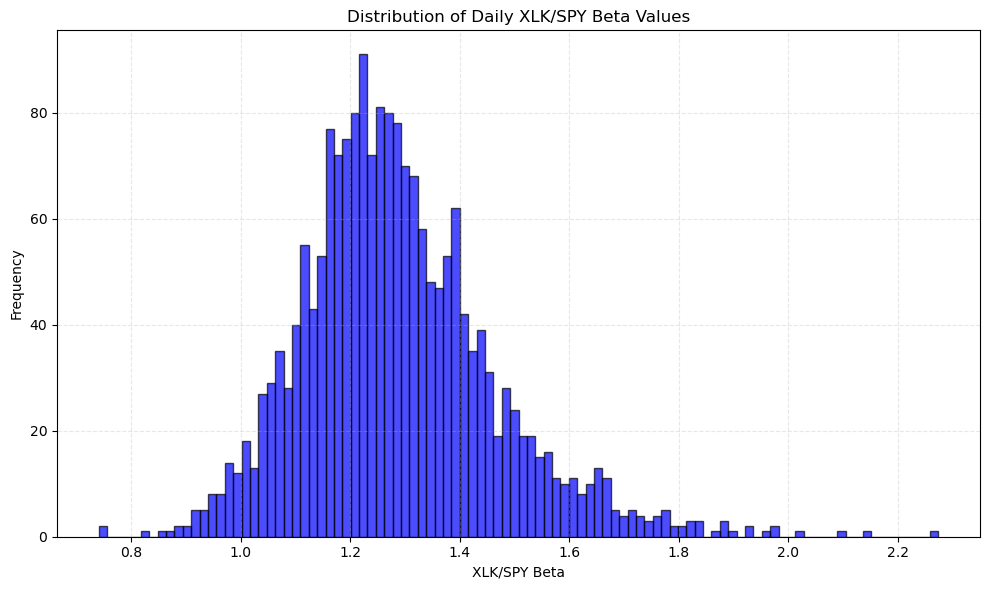

In [34]:
# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(df_SPY_XLK_betas['xlk_spy_beta'], bins=100, alpha=0.7, color='blue', edgecolor='black', linewidth=1.0)

# Add labels, title, and grid
plt.xlabel('XLK/SPY Beta')
plt.ylabel('Frequency')
plt.title('Distribution of Daily XLK/SPY Beta Values')
plt.grid(True, alpha=0.3, linestyle='--')

# Show the plot
plt.tight_layout()
plt.show()

#### 3.2 Time Series Line Plots

Let's also look at a plot of the time series, for XLK/SPY:

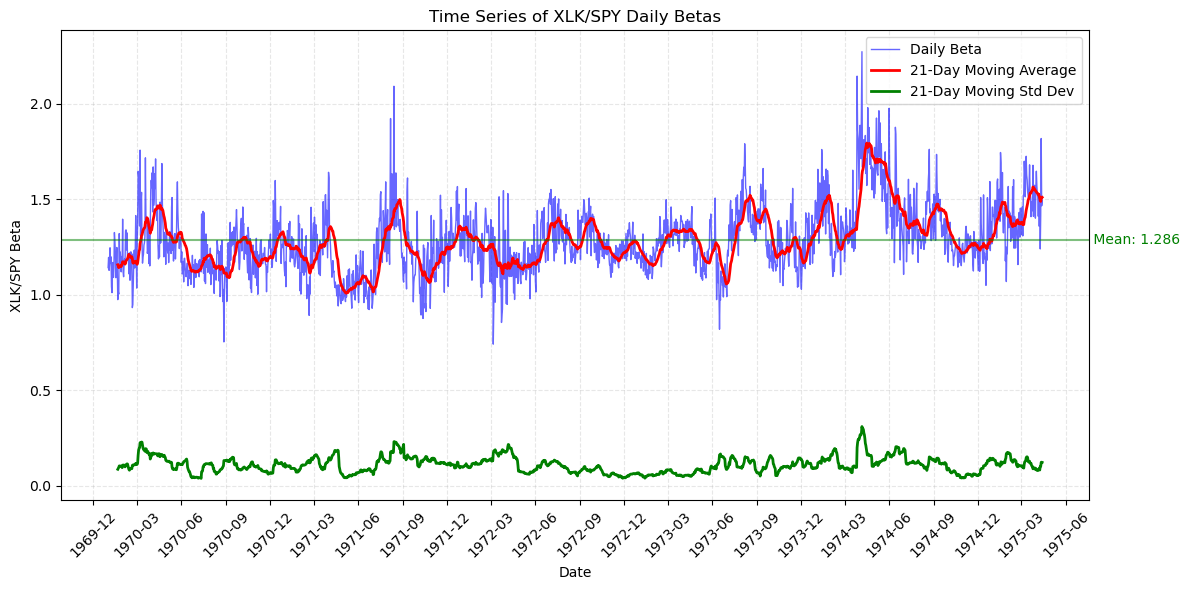

In [35]:
# Calculate the moving average and moving standard deviation of the betas
window_size = 21
df_SPY_XLK_betas['xlk_spy_beta_ma'] = df_SPY_XLK_betas['xlk_spy_beta'].rolling(window=window_size).mean()
df_SPY_XLK_betas['xlk_spy_beta_sd'] = df_SPY_XLK_betas['xlk_spy_beta'].rolling(window=window_size).std()

# Plot the time series and add the moving average and moving standard deviation
plt.figure(figsize=(12, 6))
plt.plot(df_SPY_XLK_betas.index, df_SPY_XLK_betas['xlk_spy_beta'],    linewidth=1, color='blue',  alpha=0.6, label='Daily Beta')
plt.plot(df_SPY_XLK_betas.index, df_SPY_XLK_betas['xlk_spy_beta_ma'], linewidth=2, color='red',   label=f'{window_size}-Day Moving Average')
plt.plot(df_SPY_XLK_betas.index, df_SPY_XLK_betas['xlk_spy_beta_sd'], linewidth=2, color='green', label=f'{window_size}-Day Moving Std Dev')

# Add labels, title, and grid
plt.xlabel('Date')
plt.ylabel('XLK/SPY Beta')
plt.title('Time Series of XLK/SPY Daily Betas')
plt.grid(True, alpha=0.3, linestyle='--')

# Add legend
plt.legend(loc='best')

# Format the x-axis to show dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3 months
plt.xticks(rotation=45)

# Add some statistics as text
mean_beta = df_SPY_XLK_betas['xlk_spy_beta'].mean()
plt.axhline(y=mean_beta, color='green', linestyle='-', alpha=0.5)
plt.text(plt.gca().get_xlim()[1], mean_beta, f' Mean: {mean_beta:.3f}', va='center', ha='left', color='green')

# Show the plot
plt.tight_layout()
plt.show()

# Drop any columns that were added for the plot
df_SPY_XLK_betas = df_SPY_XLK_betas[['xlk_spy_beta']]

#### 3.3 Time Series ACF Plots

Now let's look at the Autocorrelation Function (ACF) plots of the betas and beta differences, for XLK/SPY:

<Figure size 1200x600 with 0 Axes>

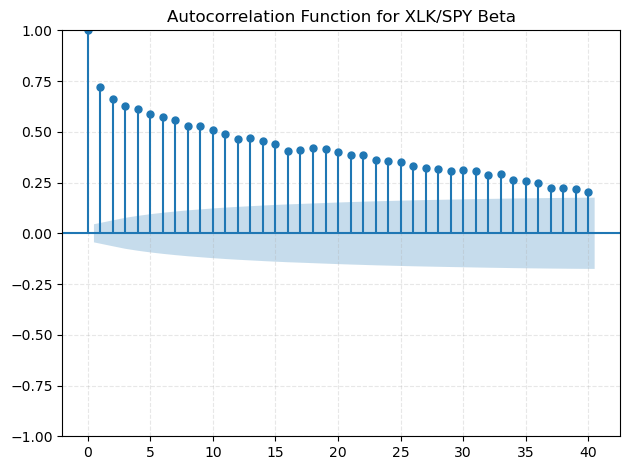

In [36]:
# Plot the autocorrelation function
plt.figure(figsize=(12, 6))
plot_acf(df_SPY_XLK_betas['xlk_spy_beta'], lags=40, alpha=0.05, title='Autocorrelation Function for XLK/SPY Beta')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

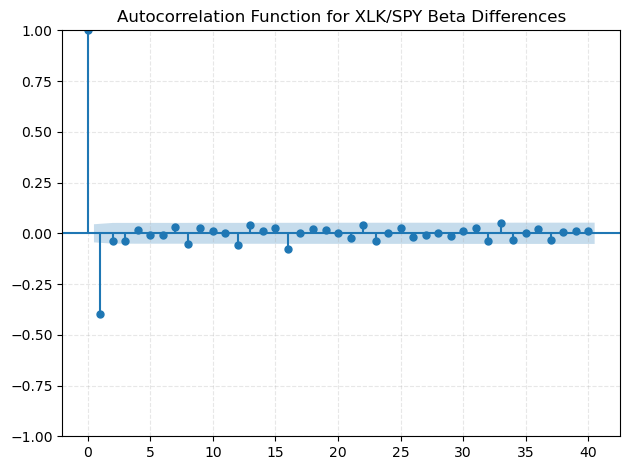

In [37]:
# Plot the autocorrelation function of the differences
plt.figure(figsize=(12, 6))
plot_acf(df_SPY_XLK_betas['xlk_spy_beta'].diff().dropna(), lags=40, alpha=0.05, title='Autocorrelation Function for XLK/SPY Beta Differences')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.4 Conclusion

From the line plot of the time series, it looked like there might be upward and downward trends in the data. However the ACF for differences shows only a negative correlation with the previous value (which is expected due to outliers), but no correlation with differences at greater lags, which indicates that there may not be significant upward or downward trends in the way beta moves over time, other than an overall reversion toward the mean. In other words, the time series might be a random walk with mean reversion. Therefore the challenge will be to see if we can do a better job of predicting beta than just using the previous day's value.

## 4 Prediction Modeling
Now we will try to develop models to predict future betas from past data. We'll use linear regression because we are trying to predict a continuous numerical value, the next day’s beta, from previous beta values using a simple linear relationship. We'll use mean squared error as our evaluation metric because it measures how far the predicted betas are from the actual betas, while penalizing larger errors more heavily.

#### 4.1 Creation of Input Features (X) and Output Target (y)

We'll start by trying regression models that only look at previous days' betas for the prediction of the next day's beta. We won't look any further back than 20 trading days for these models, so we will start by building X and y data sets where X has 20 columns representing the betas on days -20 through -1, and y is the beta for day 0.

In [38]:
# Set the window size for this feature extraction
window_size = 20

# Create data sets for features (X) and target (y) using a rolling window
data = df_SPY_XLK_betas["xlk_spy_beta"].to_numpy()
X = []
y = []
for i in range(len(data) - window_size):
    X.append(data[i : i + window_size])
    y.append(data[i + window_size])

# Convert X to a DataFrame and y to a Series
col_names = [f"lag_{k}" for k in range(window_size, 0, -1)]
X = pd.DataFrame(X, columns=col_names, index=df_SPY_XLK_betas.index[window_size:])
y = pd.Series(y, index=X.index, name="target")

Let's inspect this data:

In [39]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
X

X shape: (1909, 20)
y shape: (1909,)



,lag_20,lag_19,lag_18,lag_17,lag_16,lag_15,lag_14,lag_13,lag_12,lag_11,lag_10,lag_9,lag_8,lag_7,lag_6,lag_5,lag_4,lag_3,lag_2,lag_1
date,,,,,,,,,,,,,,,,,,,,
2018-05-30,1.142436,1.195854,1.128075,1.160622,1.246262,1.168268,1.198838,1.042513,1.011187,1.163339,1.169409,1.090750,1.138970,1.326202,1.281779,1.217625,1.089423,1.175845,1.248020,1.131115
2018-05-31,1.195854,1.128075,1.160622,1.246262,1.168268,1.198838,1.042513,1.011187,1.163339,1.169409,1.090750,1.138970,1.326202,1.281779,1.217625,1.089423,1.175845,1.248020,1.131115,0.974511
2018-06-01,1.128075,1.160622,1.246262,1.168268,1.198838,1.042513,1.011187,1.163339,1.169409,1.090750,1.138970,1.326202,1.281779,1.217625,1.089423,1.175845,1.248020,1.131115,0.974511,1.018139
2018-06-04,1.160622,1.246262,1.168268,1.198838,1.042513,1.011187,1.163339,1.169409,1.090750,1.138970,1.326202,1.281779,1.217625,1.089423,1.175845,1.248020,1.131115,0.974511,1.018139,1.003587
2018-06-05,1.246262,1.168268,1.198838,1.042513,1.011187,1.163339,1.169409,1.090750,1.138970,1.326202,1.281779,1.217625,1.089423,1.175845,1.248020,1.131115,0.974511,1.018139,1.003587,1.320771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,1.506786,1.409189,1.486215,1.439120,1.500562,1.678656,1.410804,1.548933,1.573715,1.565213,1.401642,1.564911,1.647407,1.571219,1.528343,1.510387,1.411246,1.513016,1.358996,1.500806
2025-12-26,1.409189,1.486215,1.439120,1.500562,1.678656,1.410804,1.548933,1.573715,1.565213,1.401642,1.564911,1.647407,1.571219,1.528343,1.510387,1.411246,1.513016,1.358996,1.500806,1.240195
2025-12-29,1.486215,1.439120,1.500562,1.678656,1.410804,1.548933,1.573715,1.565213,1.401642,1.564911,1.647407,1.571219,1.528343,1.510387,1.411246,1.513016,1.358996,1.500806,1.240195,1.416970


In [40]:
y

date
2018-05-30    0.974511
2018-05-31    1.018139
2018-06-01    1.003587
2018-06-04    1.320771
2018-06-05    1.166738
                ...   
2025-12-24    1.240195
2025-12-26    1.416970
2025-12-29    1.818929
2025-12-30    1.466309
2025-12-31    1.494851
Name: target, Length: 1909, dtype: float64

#### 4.2 Train/Test Split

Now we need to split the data into training and test sets. For this phase of the project, we won't worry about creating a third hold-out set for a final analysis (i.e. have separate training, development, and test sets), but to make sure there's no data leakage at this point from what will become the final test set, we'll first remove the final 309 rows from X and y so that the data for those dates, along with data for dates after 2025-12-31, is set aside for our final test set. This will leave us with 1,600 samples for the current train and test sets.

In [41]:
# Remove the final 309 rows from X and y to use later in a final test set
X = X[:-309]
y = y[:-309]

# Confirm the results
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1600, 20)
y shape: (1600,)


Because we are dealing with time series data with lagged input features, we can't shuffle the data without creating data leakage from the test set into the training set. We also can't use the usual K-fold cross-validation because then some of the folds would be using future data that should not have been seen yet when the model is validated on data in the middle of the time series. There are a few techniques to get around these problems, such as using a rolling window for multiple train and validation sets, but for now we'll get around the problem by just using the first 75% of the data as the training set and the final 25% of the data as the test set.

In [42]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

# Confirm the results
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (1200, 20)
y_train shape: (1200,)
X_test shape:  (400, 20)
y_test shape:  (400,)


#### 4.3 Baseline Models

Before fitting our first prediction model, let's calculate baseline test scores for two dummy models, one that predicts that each day's beta will be the average of all the betas in the training set, and one that predicts that each day's beta will be equal to the previous day's beta. We will use mean squared error to evaluate model performance, as explained above.

In [43]:
# Calculate the baseline MSE for a model that predicts the mean of all the betas in the training set
dummy_mean     = DummyRegressor(strategy="mean").fit(X_train, y_train)
mse_dummy_mean = mean_squared_error(y_test, dummy_mean.predict(X_test))
print(f"MSE for dummy model that predicts mean beta: {mse_dummy_mean:.6g}")

MSE for dummy model that predicts mean beta: 0.0671535


In [44]:
# Calculate the baseline MSE for a model that predicts that each day's beta is the same as the last day's beta
mse_dummy_last = mean_squared_error(y_test, np.asarray(X_test)[:, 19])
print(f"MSE for dummy model that predicts last beta: {mse_dummy_last:.6g}")

MSE for dummy model that predicts last beta: 0.0197077


The model that predicts that each day's beta is the same as the last is much better (produces a lower MSE) than the model that predicts only the mean over the whole training set, so this MSE will be the baseline score that we must beat with a better model.

#### 4.4 Regression Models

Now let's start with a regression model that uses all 20 previous days' betas to predict the next day's beta.

In [45]:
# Create a linear regression model and fit it with all 20 input features
model_20 = LinearRegression()
model_20.fit(X_train, y_train)

# Calculate the performance on the test set
y_pred_20 = model_20.predict(X_test)
mse_20    = mean_squared_error(y_test, y_pred_20)
print(f"MSE for model using 20 lagged betas: {mse_20:.6g}")

MSE for model using 20 lagged betas: 0.0159429


This performance is definitely better than the baseline model using only the last day, which is a good sign. Let's look at the model coefficients:

Intercept: 0.16748592534663165
Coefficients for each of the 20 previous days:
Day -20:  0.0228
Day -19:  0.0361
Day -18:  0.0342
Day -17:  0.0198
Day -16: -0.0649
Day -15: -0.0330
Day -14:  0.0238
Day -13:  0.0655
Day -12: -0.0844
Day -11:  0.0218
Day -10:  0.0455
Day  -9:  0.0317
Day  -8: -0.0334
Day  -7:  0.0562
Day  -6:  0.0092
Day  -5:  0.0377
Day  -4:  0.0937
Day  -3:  0.0471
Day  -2:  0.1587
Day  -1:  0.3764


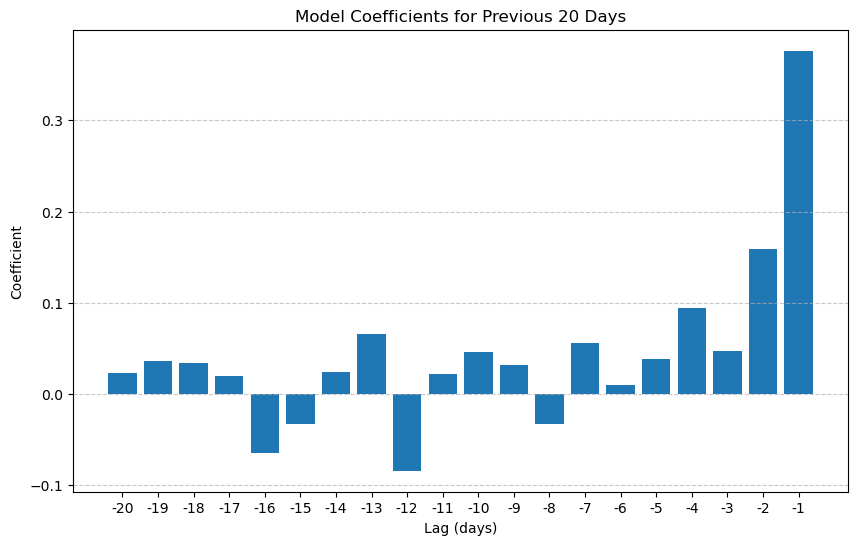

In [46]:
# Get the intercept and the coefficients
intercept    = model_20.intercept_
coefficients = model_20.coef_

# Print the intercept and the coefficients
print(f"Intercept: {intercept}")
print("Coefficients for each of the 20 previous days:")
for i, coef in enumerate(coefficients):
    day = -(20 - i)
    print(f"Day {day:>3}: {coef: .4f}")

# Plot the coefficients
plt.figure(figsize=(10, 6))
x = range(1, 21)
plt.bar(x, coefficients)
plt.xlabel('Lag (days)')
plt.ylabel('Coefficient')
plt.title('Model Coefficients for Previous 20 Days')
plt.xticks(x, range(-20, 0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The coefficients look pretty noisy for lags greater than 5 days, so it's worth trying models that look only at the previous 10 and 5 days to see how they perform against the model that looks at the previous 20 days:

MSE for baseline model (predict last): 0.0197077
MSE for model using 20 lagged betas:   0.0159429
MSE for model using 10 lagged betas:   0.0158583
MSE for model using  5 lagged betas:   0.0162413


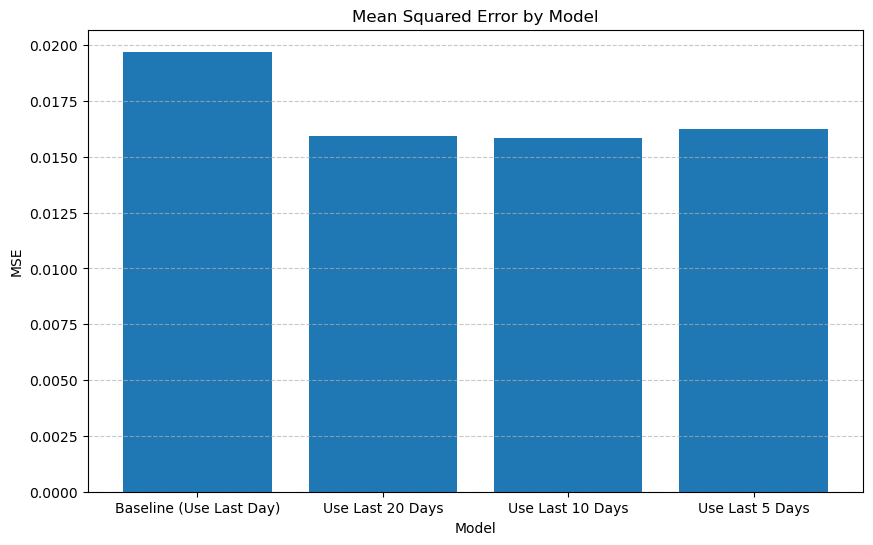

In [52]:
# Create new training and test sets with only the most recent 10 and 5 lagged features
X_train_10 = X_train.iloc[:, 10:20]
X_train_05 = X_train.iloc[:, 15:20]
X_test_10  = X_test.iloc[:, 10:20]
X_test_05  = X_test.iloc[:, 15:20]

# Create linear regression models and fit them with the most recent 10 and 5 input features
model_10 = LinearRegression().fit(X_train_10, y_train)
model_05 = LinearRegression().fit(X_train_05, y_train)

# Calculate the performances on the test set
y_pred_10 = model_10.predict(X_test_10)
y_pred_05 = model_05.predict(X_test_05)
mse_10 = mean_squared_error(y_test, y_pred_10)
mse_05 = mean_squared_error(y_test, y_pred_05)

# Print the performances for the baseline model and the models that use 20, 10, and 5 lagged betas
print(f"MSE for baseline model (predict last): {mse_dummy_last:.6g}")
print(f"MSE for model using 20 lagged betas:   {mse_20:.6g}")
print(f"MSE for model using 10 lagged betas:   {mse_10:.6g}")
print(f"MSE for model using  5 lagged betas:   {mse_05:.6g}")

# Plot the model performances
plt.figure(figsize=(10, 6))
plt.bar(["Baseline (Use Last Day)", "Use Last 20 Days", "Use Last 10 Days", "Use Last 5 Days"],
        [mse_dummy_last,            mse_20,             mse_10,             mse_05])
plt.xlabel("Model")
plt.ylabel("MSE")
plt.title("Mean Squared Error by Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('Images/ModelPerformance.png', dpi=300, bbox_inches='tight')
plt.show()

It looks like using 10 lagged features produces equivalent performance to using 20 lagged features, but dropping to 5 lagged features does produce a small drop in performance. Let's plot the coefficients for the two new models to see what's going on:

Model with 10 Lags Intercept: 0.1969474208221229
Model with 10 Lags Coefficients:
Day -10:  0.0497
Day  -9:  0.0409
Day  -8: -0.0336
Day  -7:  0.0584
Day  -6:  0.0105
Day  -5:  0.0313
Day  -4:  0.1049
Day  -3:  0.0469
Day  -2:  0.1532
Day  -1:  0.3786

Model with  5 Lags Intercept: 0.24694308746615723
Model with  5 Lags Coefficients:
Day  -5:  0.0677
Day  -4:  0.1191
Day  -3:  0.0614
Day  -2:  0.1649
Day  -1:  0.3873


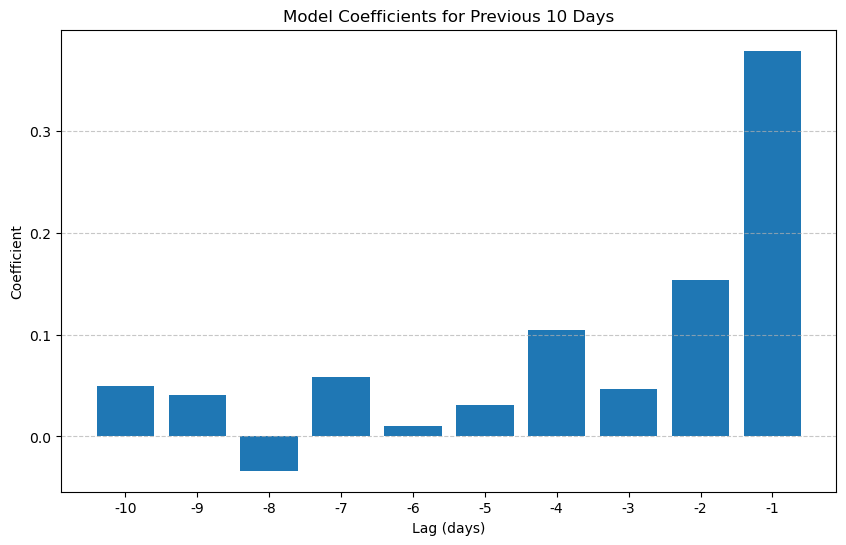

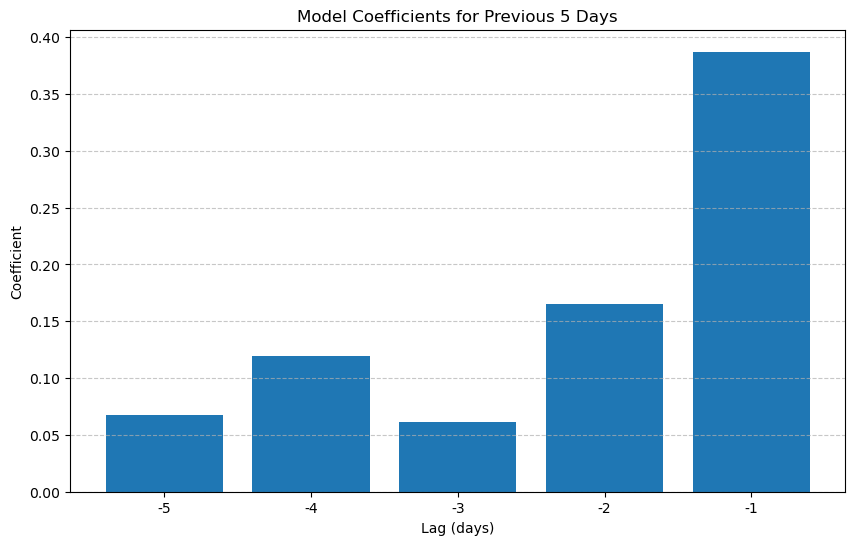

In [49]:
# Get the intercepts and the coefficients for the two new models
intercept_10    = model_10.intercept_
intercept_05    = model_05.intercept_
coefficients_10 = model_10.coef_
coefficients_05 = model_05.coef_

# Print the intercept and the coefficients for the model with 10 lagged features
print(f"Model with 10 Lags Intercept: {intercept_10}")
print("Model with 10 Lags Coefficients:")
for i, coef in enumerate(coefficients_10):
    day = -(10 - i)
    print(f"Day {day:>3}: {coef: .4f}")

# Print the intercept and the coefficients for the model with 5 lagged features
print()
print(f"Model with  5 Lags Intercept: {intercept_05}")
print("Model with  5 Lags Coefficients:")
for i, coef in enumerate(coefficients_05):
    day = -(5 - i)
    print(f"Day {day:>3}: {coef: .4f}")

# Plot the coefficients for the model with 10 lagged features
plt.figure(figsize=(10, 6))
x = range(1, 11)
plt.bar(x, coefficients_10)
plt.xlabel('Lag (days)')
plt.ylabel('Coefficient')
plt.title('Model Coefficients for Previous 10 Days')
plt.xticks(x, range(-10, 0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot the coefficients for the model with 5 lagged features
plt.figure(figsize=(10, 6))
x = range(1, 6)
plt.bar(x, coefficients_05)
plt.xlabel('Lag (days)')
plt.ylabel('Coefficient')
plt.title('Model Coefficients for Previous 5 Days')
plt.xticks(x, range(-5, 0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on how the coefficients drop over time, it looks like the sweet spot for best performance is somewhere between 5 and 10 lagged days. We'll take a closer look and optimize the model when we do further analysis.

***THIS CONCLUDES THE EXPLORATORY DATA ANALYSIS***